In [30]:
from astropy.io import fits
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube
import numpy as np
import json

import sys
from pathlib import Path


In [2]:
# Add path to py_modules 

sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

#from turb_utils import make_extended, make_3dfield
import strucfunc
#import bfunc
#import bplot

In [21]:
name = 'fake_cube_sigE1_finite_m330_r32_N512'
hdul = fits.open(name + '.fits')

In [4]:
hdul.info()

Filename: fake_cube_sigE1_finite_m330_r32_N512.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   (512, 512, 80)   float64   


In [5]:
cube    = SpectralCube.read(hdul[0])
sb      = cube.moment0().value
vv     = cube.moment1().value


signorm = vv.std()
vv   /= signorm
print(signorm)

0.15674216075224537


In [25]:
pix      = 1
pc       = 1
s0       = 0
box_size = 512

In [7]:
m = ~np.isfinite(sb*vv) | (sb < 0.0)

sb[m] = 0.0
vv[m] = np.nanmean(vv)
sb /= sb.max()

good = (~m) & (sb > 0.001)

In [10]:
rslt = strucfunc.strucfunc_numba_parallel(vv, wmap=sb, dlogr=0.05)

In [11]:
rslt["Unweighted mean velocity"] = np.mean(vv[good])
rslt["Unweighted sigma^2"] = np.var(vv[good])
v0w = rslt["Weighted mean velocity"] = np.average(vv, weights=sb)
rslt["Weighted sigma^2"] = np.average((vv - v0w)**2, weights=sb)

In [16]:
b2    = rslt['Unweighted B(r)'] 
e_b2  = b2  *.1

b2w   = rslt['Weighted B(r)']
e_b2w = b2w  *.1

s     = 10**rslt['log10 r'] * pix * pc
e_s   = s  *.1

sig2  = rslt['Unweighted sigma^2']
sig   = sig2**0.5

sig2w = rslt['Weighted sigma^2']

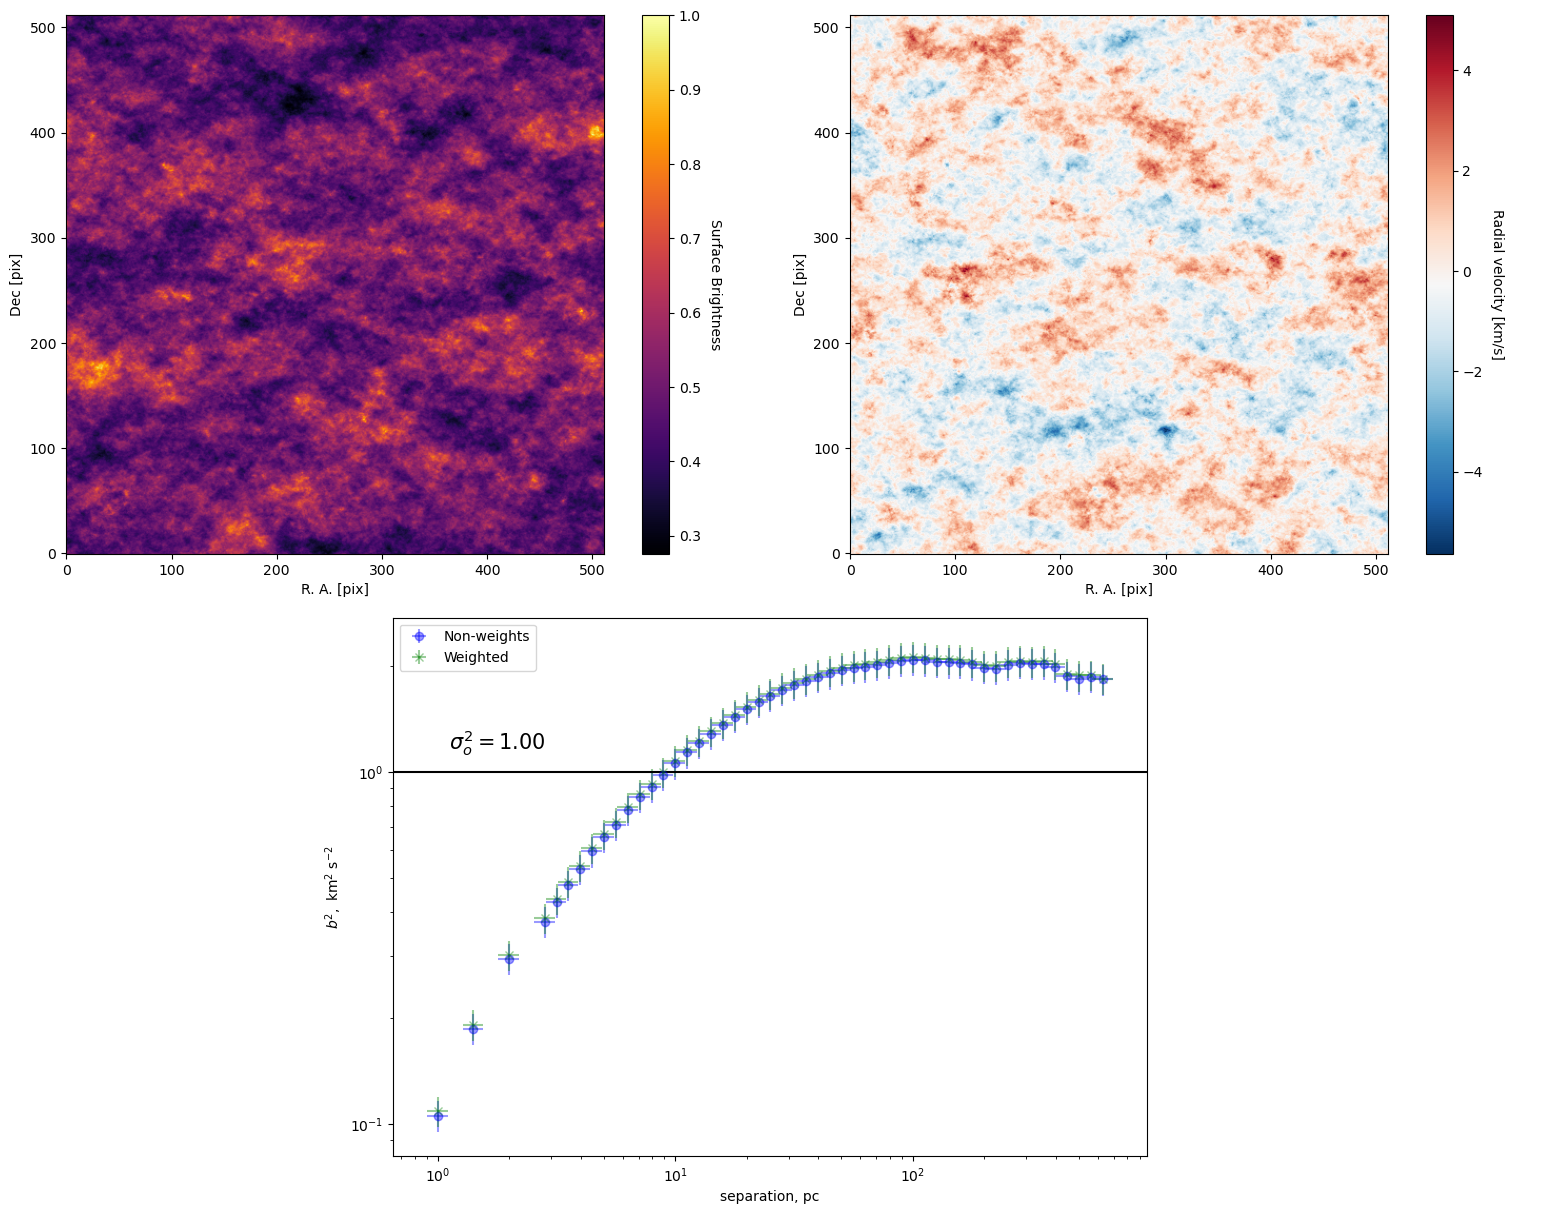

In [34]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Top-Left: Surface Brightness
im0 = axs[0, 0].imshow(sb, cmap='inferno')
cbar0 = fig.colorbar(im0, ax=axs[0, 0])
cbar0.set_label('Surface Brightness', rotation=270, labelpad=15)
axs[0, 0].set_xlabel('R. A. [pix]')
axs[0, 0].set_ylabel('Dec [pix]')
axs[0, 0].invert_yaxis()

# Top-Right: Radial Velocity
im1 = axs[0, 1].imshow(vv, cmap='RdBu_r')
cbar1 = fig.colorbar(im1, ax=axs[0, 1])
cbar1.set_label('Radial velocity [km/s]', rotation=270, labelpad=15)
axs[0, 1].set_xlabel('R. A. [pix]')
axs[0, 1].set_ylabel('Dec [pix]')
axs[0, 1].invert_yaxis()

# Bottom-Right: turn off
axs[1, 1].axis('off')

# Bottom-Left: errorbar plot (center it)
# Do this BEFORE tight_layout so we avoid its override
fig.tight_layout()
pos = axs[1, 0].get_position()
new_x = (pos.x0 + axs[1, 1].get_position().x1) / 2 - pos.width / 2
axs[1, 0].set_position([new_x, pos.y0, pos.width, pos.height])

# Now plot
axs[1, 0].errorbar(s, b2, yerr=e_b2, xerr=e_s, fmt='o', alpha=0.4, color="blue", label='Non-weights')
axs[1, 0].errorbar(s, b2w, yerr=e_b2w, xerr=e_s, fmt='x', alpha=0.4, color="green", label='Weighted')

# Plot horizontal line at sig2
axs[1, 0].axhline(sig2, color='black', linestyle='-')

# Add text label near the line (adjust position as needed)
axs[1, 0].text(s[5], sig2 * 1.1, f"$\\sigma^2_o = {sig2:.2f}$", fontsize = 15, color='black', ha='center', va='bottom')


axs[1, 0].set(xscale='log', yscale='log',
              xlabel='separation, pc',
              ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$')
axs[1, 0].legend()

plt.savefig(f"{name}.png", bbox_inches='tight')

plt.show()


In [28]:
data_export = {   
       'name'     : name, 
        'pc'      : pc,
        's0'      : s0,    
        'pix'     : pix,
        'box_size': box_size,
        'sig2'    : sig2,
        's'       : s,
        'b2'      : b2,
#        'SF'      : rslt,
#        'sb'      : sb,
#        'vv'      : vv,
}

data_export

{'name': 'fake_cube_sigE1_finite_m330_r32_N512',
 'pc': 1,
 's0': 0,
 'pix': 1,
 'box_size': 512,
 'sig2': 1.0000000000000002,
 's': array([  1.        ,   1.12201845,   1.25892541,   1.41253754,
          1.58489319,   1.77827941,   1.99526231,   2.23872114,
          2.51188643,   2.81838293,   3.16227766,   3.54813389,
          3.98107171,   4.46683592,   5.01187234,   5.62341325,
          6.30957344,   7.07945784,   7.94328235,   8.91250938,
         10.        ,  11.22018454,  12.58925412,  14.12537545,
         15.84893192,  17.7827941 ,  19.95262315,  22.38721139,
         25.11886432,  28.18382931,  31.6227766 ,  35.48133892,
         39.81071706,  44.66835922,  50.11872336,  56.23413252,
         63.09573445,  70.79457844,  79.43282347,  89.12509381,
        100.        , 112.20184543, 125.89254118, 141.25375446,
        158.48931925, 177.827941  , 199.5262315 , 223.87211386,
        251.18864315, 281.83829313, 316.22776602, 354.81338923,
        398.10717055, 446.68359215, 

In [31]:
class MyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)

In [32]:
jsonfilename = name + ".json"
with open(jsonfilename, "w") as f:
    json.dump(data_export, fp=f, indent=3, cls=MyEncoder)